# Home Credit Scorecard Model

**Goal:** memprediksi apakah pemohon akan gagal bayar, lalu mengubahnya menjadi
credit score + kebijakan persetujuan yang menguntungkan.

**Data:** `application_train.csv` (tabel utama, ~122 kolom).
**Model:** Logistic Regression (baseline) + LightGBM (champion).
**Metric:** ROC-AUC, diukur **out-of-fold** (held-out), bukan di data training.
**Output akhir:** credit score, 3 tier risiko, dan estimasi Net Profit per kebijakan.

Alur: (0) Setup → (1) Load & Cleaning → (2) EDA → (3) Modeling & Perbandingan →
(4) Kalibrasi & Scorecard → (5) Tier & Net Profit → (6) Feature Importance → (7) Simpan.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")
RND = 42  # random seed agar hasil bisa direproduksi

print("setup ok")

setup ok


## Fase 1 · Load & Pembersihan Data

Kita pakai **satu tabel** (`application_train`) agar setiap fitur bisa dijelaskan.
Tiga pembersihan penting:
1. `DAYS_EMPLOYED = 365243` adalah kode placeholder untuk pensiunan (bukan ~1000
   tahun kerja) → diubah jadi kosong (NaN).
2. Ada satu record dengan income **117 juta** (jelas salah input) yang sempat
   mengacaukan analisis → dibuang.
3. `CODE_GENDER` dibersihkan lalu **dibuang dari fitur** — memakai jenis kelamin
   dalam keputusan kredit melanggar prinsip fair-lending.

In [37]:
# Sesuaikan ke folder yang berisi application_train.csv
DATA_DIR = Path(r"D:\Bootcamp\Rakamin\data")
OUT_DIR = Path(r"D:\Bootcamp\Rakamin\outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Asumsi ekonomi untuk simulasi Net Profit (ganti dgn angka tim finance bila ada)
MARGIN = 0.15   # keuntungan jika nasabah BAIK   = MARGIN * AMT_CREDIT
LGD    = 0.65   # kerugian   jika nasabah GAGAL  = LGD * AMT_CREDIT
print(f"Break-even PD = {MARGIN / (LGD + MARGIN):.3f}  "
      f"(di bawah ini, pemohon masih untung secara ekspektasi)")

# Atribut terproteksi: TIDAK boleh dipakai model (isu fair-lending / etika kredit)
DROP_PROTECTED = ["CODE_GENDER"]

Break-even PD = 0.187  (di bawah ini, pemohon masih untung secara ekspektasi)


In [38]:
app = pd.read_csv(DATA_DIR / "application_train.csv")
print("shape awal:", app.shape)

# 1) Anomali DAYS_EMPLOYED (placeholder pensiunan) -> NaN
app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)

# 2) Outlier income 117 juta (error input) -> buang
app = app[app["AMT_INCOME_TOTAL"] < 1e8].copy()

# 3) Gender 'XNA' -> NaN (kolomnya sendiri dibuang di Sel 6 lewat DROP_PROTECTED)
app.loc[app["CODE_GENDER"] == "XNA", "CODE_GENDER"] = np.nan

print("shape bersih:", app.shape, "| default rate:", f"{app['TARGET'].mean():.2%}")

shape awal: (307511, 122)
shape bersih: (307510, 122) | default rate: 8.07%


In [39]:
# Fitur domain ringkas (yang terbukti prediktif & mudah dijelaskan)
ext = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
app["EXT_SOURCE_MEAN"] = app[ext].mean(axis=1)              # skor risiko eksternal
app["CREDIT_INCOME_RATIO"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"]
app["ANNUITY_INCOME_RATIO"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"]
app["CREDIT_TERM"] = app["AMT_ANNUITY"] / app["AMT_CREDIT"]  # proksi tenor
app["AGE_YEARS"] = (-app["DAYS_BIRTH"] / 365).round(1)

# Target & nilai pinjaman (untuk simulasi profit nanti)
y = app["TARGET"].astype(int).values
amt_credit = app["AMT_CREDIT"].fillna(app["AMT_CREDIT"].median()).values

# Buang target, ID, dan atribut terproteksi -> sisanya jadi fitur
drop_cols = ["TARGET", "SK_ID_CURR"] + DROP_PROTECTED
X = app.drop(columns=[c for c in drop_cols if c in app])

# Ubah kolom kategorikal (teks) menjadi angka
for c in X.select_dtypes(include="object").columns:
    X[c] = pd.factorize(X[c])[0]
X = X.replace([np.inf, -np.inf], np.nan)

feature_names = X.columns.tolist()
print("X:", X.shape, "| #fitur:", len(feature_names))

X: (307510, 124) | #fitur: 124


## Fase 2 · EDA & Business Insight

Sebelum modeling, kita gali pola yang bisa jadi rekomendasi bisnis. Empat hal:
distribusi gagal bayar, default rate per jenis penghasilan & usia, dan seberapa
kuat `EXT_SOURCE` membedakan nasabah baik vs buruk.

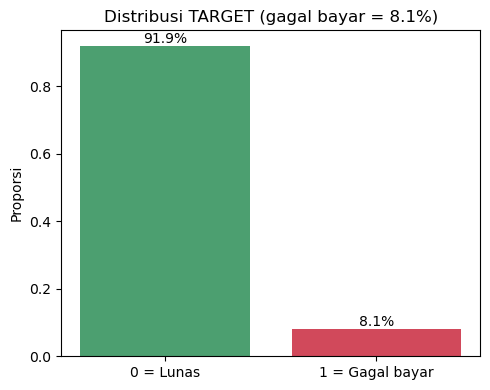

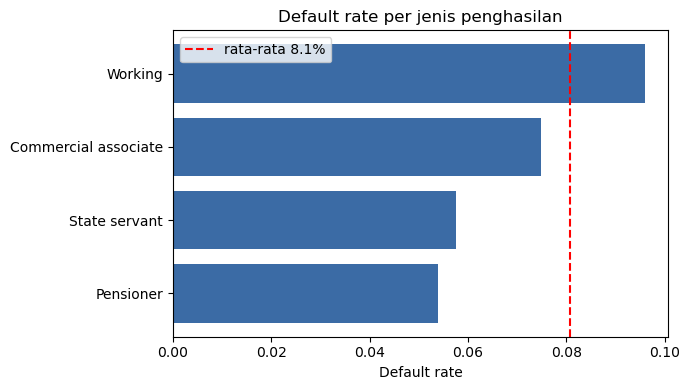

                        size  default_pct
NAME_INCOME_TYPE                         
Pensioner              55362          5.4
State servant          21703          5.8
Commercial associate   71617          7.5
Working               158773          9.6


In [40]:
# (a) Seberapa timpang kelas gagal bayar
plt.figure(figsize=(5, 4))
vc = app["TARGET"].value_counts(normalize=True).sort_index()
plt.bar(["0 = Lunas", "1 = Gagal bayar"], vc.values, color=["#4C9F70", "#D1495B"])
for i, v in enumerate(vc.values):
    plt.text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.title(f"Distribusi TARGET (gagal bayar = {vc.get(1, 0):.1%})"); plt.ylabel("Proporsi")
plt.tight_layout(); plt.show()

# (b) Jenis penghasilan mana yang paling berisiko? (dasar campaign akuisisi)
g = (app.groupby("NAME_INCOME_TYPE")["TARGET"].agg(["mean", "size"])
     .query("size >= 500").sort_values("mean"))
plt.figure(figsize=(7, 4))
plt.barh(g.index, g["mean"], color="#3B6BA5")
plt.axvline(app["TARGET"].mean(), color="red", ls="--",
            label=f"rata-rata {app['TARGET'].mean():.1%}")
plt.xlabel("Default rate"); plt.title("Default rate per jenis penghasilan"); plt.legend()
plt.tight_layout(); plt.show()
print(g.assign(default_pct=(g["mean"] * 100).round(1))[["size", "default_pct"]].to_string())

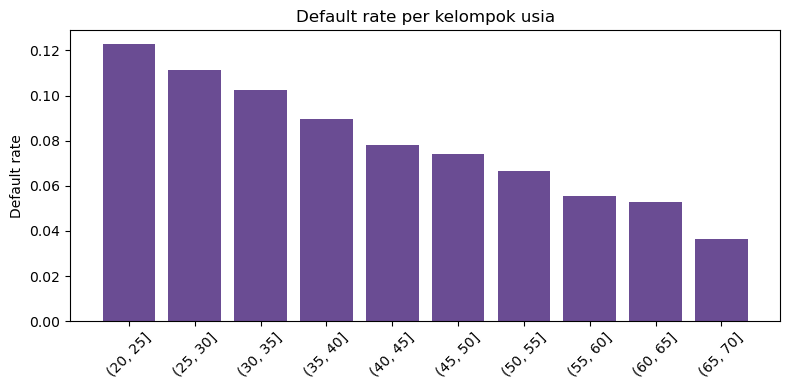

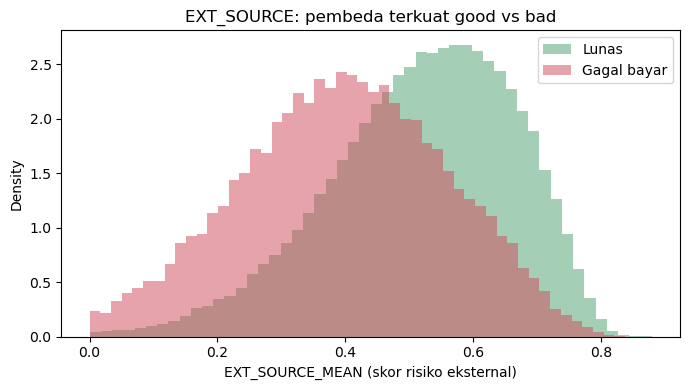

In [41]:
# (a) Risiko menurun seiring usia
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
ageband = pd.cut(app["AGE_YEARS"], bins)
g_age = app.groupby(ageband, observed=True)["TARGET"].mean()
plt.figure(figsize=(8, 4))
plt.bar(g_age.index.astype(str), g_age.values, color="#6A4C93")
plt.xticks(rotation=45); plt.ylabel("Default rate")
plt.title("Default rate per kelompok usia"); plt.tight_layout(); plt.show()

# (b) EXT_SOURCE memisahkan baik vs buruk -> fitur paling prediktif
plt.figure(figsize=(7, 4))
for t, c, lbl in [(0, "#4C9F70", "Lunas"), (1, "#D1495B", "Gagal bayar")]:
    app.loc[app["TARGET"] == t, "EXT_SOURCE_MEAN"].plot(
        kind="hist", bins=50, density=True, alpha=0.5, color=c, label=lbl)
plt.xlabel("EXT_SOURCE_MEAN (skor risiko eksternal)"); plt.ylabel("Density")
plt.title("EXT_SOURCE: pembeda terkuat good vs bad"); plt.legend()
plt.tight_layout(); plt.show()

### Insight Utama

**1 · EXT_SOURCE adalah pemisah risiko terkuat.** Distribusi nasabah baik jelas
bergeser ke kanan vs yang gagal bayar. → *Action:* jadikan tulang punggung scorecard.
Untuk pemohon **tanpa** EXT_SOURCE (thin-file), jangan auto-reject — arahkan ke
manual review. *Missing ≠ buruk.*

**2 · Segmen risiko-rendah justru kecil porsinya.** PNS (*State servant*) & pensiunan
default-nya jauh di bawah rata-rata 8%, sementara *Working* (mayoritas) tertinggi.
→ *Action:* campaign akuisisi tertarget ke PNS & pensiunan menurunkan kerugian
agregat tanpa memperketat kebijakan.

**Catatan jujur:** angka per-segmen ini **univariat** (belum mengontrol faktor lain
seperti usia/income). Cukup untuk menentukan target akuisisi, tapi jangan diklaim
sebagai sebab-akibat. Usia menurunkan risiko, tapi **tidak** dipakai untuk menolak
(fair-lending) — hanya untuk limit/pricing.

## Fase 3 · Modeling: Logistic Regression vs LightGBM

Tugas mewajibkan ≥2 model (salah satunya Logistic Regression). Kita pakai **satu
fungsi `oof_predict`** untuk keduanya agar perbandingannya adil.

**Out-of-fold (OOF)** = data dibagi 5 bagian; tiap bagian diprediksi oleh model yang
dilatih pada 4 bagian lain. Jadi setiap prediksi dibuat untuk data yang **belum
pernah dilihat** model. Inilah AUC jujur — beda dengan mengukur di data training
(yang akan menggelembung tidak realistis).

- **Logistic Regression** = baseline sederhana & interpretable (pakai pipeline:
  imputasi → scaling → model).
- **LightGBM** = model kuat yang menangkap pola non-linear.

In [44]:
def make_logreg():
    """Baseline interpretable. Pipeline: isi missing -> skala -> regresi logistik."""
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=RND))


def make_lgbm():
    """Champion. class_weight='balanced' menangani imbalance 8%."""
    return LGBMClassifier(
       # di Sel 12, ganti baris n_estimators
n_estimators=1200, learning_rate=0.02, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=0.1,
        class_weight="balanced", random_state=RND, n_jobs=-1, verbose=-1)


def oof_predict(make_model, X, y, calibrate=False):
    """Prediksi out-of-fold: tiap baris diprediksi model yang TIDAK dilatih padanya.
    calibrate=True membungkus model dgn kalibrasi isotonic (dipakai utk champion)."""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
    oof = np.zeros(len(y))
    for tr, va in skf.split(X, y):
        model = make_model()
        if calibrate:
            model = CalibratedClassifierCV(model, method="isotonic", cv=3)
        model.fit(X.iloc[tr], y[tr])
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
    return oof


print("model & oof_predict siap")

model & oof_predict siap


Melatih Logistic Regression (OOF)...
Melatih LightGBM (OOF + kalibrasi)... butuh beberapa menit

              model    AUC   Gini
Logistic Regression 0.7415 0.4830
           LightGBM 0.7641 0.5283


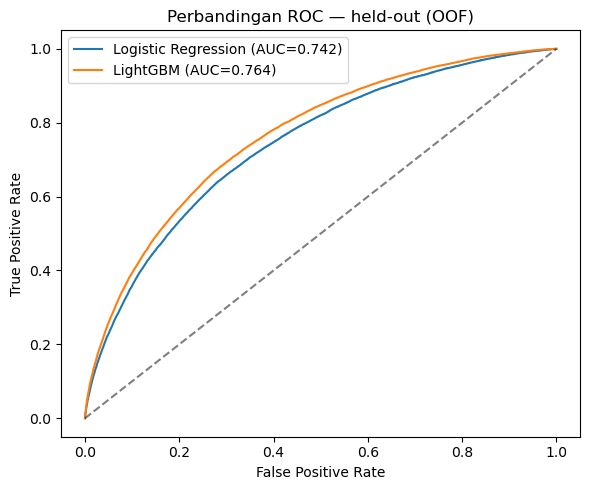

In [45]:
from sklearn.metrics import roc_curve

print("Melatih Logistic Regression (OOF)...")
oof_lr = oof_predict(make_logreg, X, y)

print("Melatih LightGBM (OOF + kalibrasi)... butuh beberapa menit")
oof_lgb = oof_predict(make_lgbm, X, y, calibrate=True)   # dipakai lagi di Fase 4 & 5

# --- Tabel perbandingan ---
results = pd.DataFrame({
    "model": ["Logistic Regression", "LightGBM"],
    "AUC": [roc_auc_score(y, oof_lr), roc_auc_score(y, oof_lgb)],
})
results["Gini"] = 2 * results["AUC"] - 1
print("\n" + results.round(4).to_string(index=False))

# --- Kurva ROC ---
plt.figure(figsize=(6, 5))
for oof, lbl in [(oof_lr, "Logistic Regression"), (oof_lgb, "LightGBM")]:
    fpr, tpr, _ = roc_curve(y, oof)
    plt.plot(fpr, tpr, label=f"{lbl} (AUC={roc_auc_score(y, oof):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Perbandingan ROC — held-out (OOF)"); plt.legend()
plt.tight_layout(); plt.show()

## Fase 4 · Kalibrasi & Scorecard

Dua langkah:
1. **Kalibrasi** — karena `class_weight='balanced'` mendistorsi probabilitas, kita
   sudah membungkus LightGBM dengan isotonic calibration (`oof_lgb`). Kita buktikan:
   saat model bilang "PD 8%", kenyataannya juga ~8%. Ini wajib agar angka Net Profit
   nanti bisa dipercaya.
2. **Scorecard** — ubah PD menjadi angka credit score ala FICO (skor tinggi = risiko
   rendah) dengan rumus log-odds standar. Judul tugas memang "Scorecard Model".

In [46]:
def prob_to_score(pd_default, pdo=20, base_score=600, base_odds=50):
    """Ubah PD jadi credit score. Skor TINGGI = risiko RENDAH.
    pdo=poin utk menggandakan odds, base_score/base_odds=titik acuan."""
    pd_clip = np.clip(pd_default, 1e-6, 1 - 1e-6)
    odds_good = (1 - pd_clip) / pd_clip
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    return offset + factor * np.log(odds_good)


def ks_statistic(y_true, y_score):
    """KS: seberapa jauh distribusi skor nasabah baik vs buruk terpisah."""
    d = pd.DataFrame({"y": y_true, "s": y_score}).sort_values("s")
    cb = (d["y"] == 1).cumsum() / max((d["y"] == 1).sum(), 1)
    cg = (d["y"] == 0).cumsum() / max((d["y"] == 0).sum(), 1)
    return float(np.max(np.abs(cb - cg)))


def calibration_table(y_true, pd_pred, n_bins=10):
    """Bukti kalibrasi: per desil PD, bandingkan PD prediksi vs default aktual.
    Gap kecil = kalibrasi baik."""
    d = pd.DataFrame({"y": y_true, "pd": pd_pred})
    d["bin"] = pd.qcut(d["pd"], q=n_bins, duplicates="drop")
    rep = d.groupby("bin", observed=True).agg(
        n=("y", "size"), pred_pd=("pd", "mean"), actual_rate=("y", "mean"))
    rep["gap"] = rep["actual_rate"] - rep["pred_pd"]
    return rep


print("fungsi scorecard siap")

fungsi scorecard siap


Skor:  min=269  median=570  max=886
KS  = 0.3939  |  Gini = 0.5283

                      n  pred_pd  actual_rate     gap
bin                                                  
(-0.001, 0.0172]  30865   0.0123       0.0108 -0.0015
(0.0172, 0.0243]  30637   0.0207       0.0190 -0.0017
(0.0243, 0.0316]  30761   0.0277       0.0262 -0.0015
(0.0316, 0.0412]  30745   0.0362       0.0348 -0.0014
(0.0412, 0.0532]  30747   0.0471       0.0463 -0.0008
(0.0532, 0.068]   30756   0.0603       0.0605  0.0002
(0.068, 0.0894]   30746   0.0778       0.0765 -0.0014
(0.0894, 0.124]   30768   0.1054       0.1084  0.0029
(0.124, 0.183]    30746   0.1502       0.1482 -0.0020
(0.183, 0.999]    30739   0.2694       0.2767  0.0073


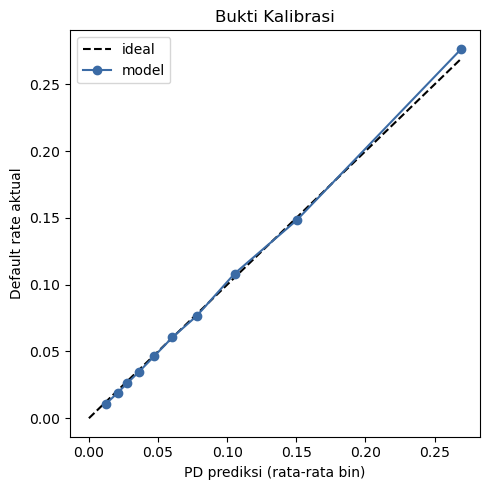

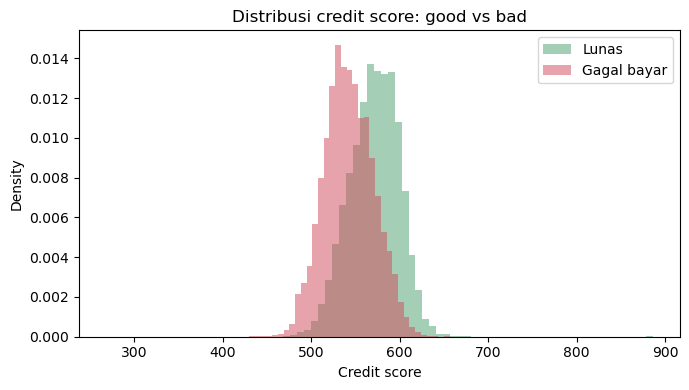

In [47]:
score = prob_to_score(oof_lgb)
print(f"Skor:  min={score.min():.0f}  median={np.median(score):.0f}  max={score.max():.0f}")
print(f"KS  = {ks_statistic(y, oof_lgb):.4f}  |  Gini = {2*roc_auc_score(y, oof_lgb)-1:.4f}")

# Bukti kalibrasi: tabel + grafik
rep = calibration_table(y, oof_lgb)
print("\n" + rep.round(4).to_string())

plt.figure(figsize=(5, 5))
m = rep["pred_pd"].max()
plt.plot([0, m], [0, m], "k--", label="ideal")
plt.plot(rep["pred_pd"], rep["actual_rate"], "o-", color="#3B6BA5", label="model")
plt.xlabel("PD prediksi (rata-rata bin)"); plt.ylabel("Default rate aktual")
plt.title("Bukti Kalibrasi"); plt.legend(); plt.tight_layout(); plt.show()

# Distribusi skor: nasabah baik vs buruk
plt.figure(figsize=(7, 4))
for t, c, lbl in [(0, "#4C9F70", "Lunas"), (1, "#D1495B", "Gagal bayar")]:
    pd.Series(score[y == t]).plot(kind="hist", bins=60, density=True,
                                  alpha=0.5, color=c, label=lbl)
plt.xlabel("Credit score"); plt.ylabel("Density")
plt.title("Distribusi credit score: good vs bad"); plt.legend()
plt.tight_layout(); plt.show()

## Fase 5 · Tier Risiko & Simulasi Net Profit

Inti rekomendasi bisnis — bagian yang membuat kita melampaui reviewer (yang berhenti
di feature importance). Skor dibagi **3 tier berdasarkan EKONOMI**, bukan kuantil:

- **A — Auto-Approve** : PD ≤ 5% → sangat aman, setujui otomatis (limit & pricing terbaik).
- **B — Review** : 5% < PD < break-even (18,7%) → masih untung, tapi lewat scrutiny.
- **C — Reject** : PD ≥ break-even → rugi secara ekspektasi, tolak.

Lalu kita hitung Net Profit tiap kebijakan. Menolak hanya zona-rugi (C) memaksimalkan
profit; menolak sepertiga teratas (cara kuantil) justru membuang nasabah menguntungkan.

In [48]:
def expected_profit(pd_default, amt):
    """E[profit | disetujui] = (1-PD)*MARGIN*AMT - PD*LGD*AMT."""
    return (1 - pd_default) * MARGIN * amt - pd_default * LGD * amt


break_even = MARGIN / (LGD + MARGIN)   # 0.187


def assign_tier(pd_default):
    """3 tier berbasis ekonomi (bukan kuantil)."""
    return np.where(pd_default >= break_even, "C_Reject",
           np.where(pd_default <= 0.05, "A_AutoApprove", "B_Review"))


def tier_summary(tier, score, pd_default, y):
    d = pd.DataFrame({"tier": tier, "score": score, "pd": pd_default, "default": y})
    s = d.groupby("tier").agg(
        n=("default", "size"), default_rate=("default", "mean"),
        avg_pd=("pd", "mean"), score_min=("score", "min"), score_max=("score", "max"))
    s["pop_pct"] = s["n"] / s["n"].sum()
    return s.sort_values("score_min", ascending=False)


def net_profit_table(pd_default, amt):
    ep = expected_profit(pd_default, amt)
    tier = assign_tier(pd_default)
    approve_frac = {"A_AutoApprove": 1.0, "B_Review": 1.0, "C_Reject": 0.0}
    rows = []
    for name, mask in {"Approve_All": np.ones(len(ep), bool),
                       "Reject_All": np.zeros(len(ep), bool),
                       "Model_Optimal": ep > 0}.items():
        rows.append([name, mask.mean(), ep[mask].sum()])
    frac = np.array([approve_frac[t] for t in tier])
    rows.append(["Three_Tier_Policy", frac.mean(), (ep * frac).sum()])
    out = pd.DataFrame(rows, columns=["policy", "approved_pct", "net_profit"])
    base = out.loc[out.policy == "Approve_All", "net_profit"].iloc[0]
    out["uplift"] = out["net_profit"] - base
    return out


def plot_profit_curve(pd_default, amt, score):
    ep = expected_profit(pd_default, amt)
    order = np.argsort(score); s_sorted = score[order]
    cum = np.cumsum(ep[order][::-1])[::-1]      # profit bila approve skor >= cutoff
    best = int(np.argmax(cum))
    plt.figure(figsize=(8, 5))
    plt.plot(s_sorted, cum, color="#3B6BA5")
    plt.axvline(s_sorted[best], ls="--", color="green",
                label=f"cutoff optimal = {s_sorted[best]:.0f}")
    plt.xlabel("Credit score cutoff (approve jika skor >= cutoff)")
    plt.ylabel("Expected Net Profit"); plt.title("Net Profit vs Approval Cutoff")
    plt.legend(); plt.tight_layout(); plt.show()
    return s_sorted[best]


print("fungsi bisnis siap")

fungsi bisnis siap


=== Komposisi & validasi tier (default rate harus naik A->B->C) ===
                    n  default_rate  avg_pd  score_min  score_max  pop_pct
tier                                                                      
A_AutoApprove  145936        0.0261  0.0276   572.0832   885.7542   0.4746
B_Review       132742        0.0970  0.0969   529.4328   572.0802   0.4317
C_Reject        28832        0.2822  0.2750   268.9233   529.4287   0.0938

=== Simulasi Net Profit (asumsi MARGIN=15%, LGD=65%) ===
           policy  approved_%  net_profit_M  uplift_M
      Approve_All       100.0         16.64      0.00
       Reject_All         0.0          0.00    -16.64
    Model_Optimal        90.6         17.62      0.99
Three_Tier_Policy        90.6         17.62      0.99



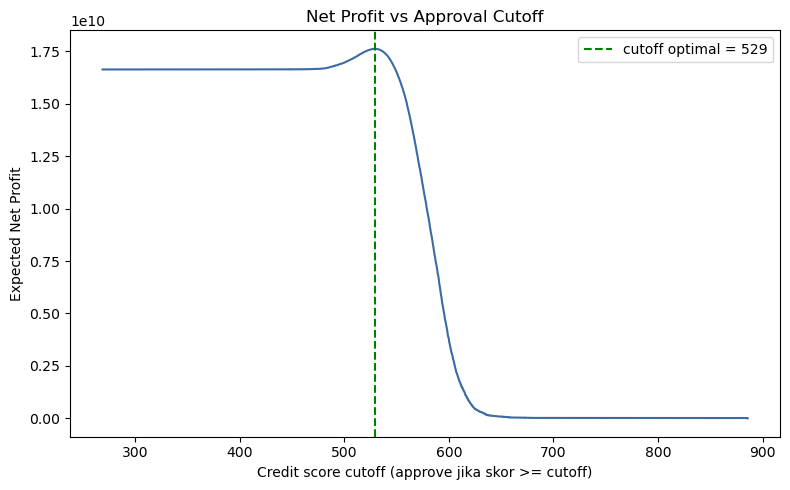

Cutoff skor optimal = 529 (setujui pemohon dengan skor >= ini)


In [49]:
tier = assign_tier(oof_lgb)

print("=== Komposisi & validasi tier (default rate harus naik A->B->C) ===")
print(tier_summary(tier, score, oof_lgb, y).round(4).to_string())

print("\n=== Simulasi Net Profit (asumsi MARGIN=15%, LGD=65%) ===")
tbl = net_profit_table(oof_lgb, amt_credit)
disp = tbl.copy()
disp["approved_%"] = (disp["approved_pct"] * 100).round(1)
disp["net_profit_M"] = (disp["net_profit"] / 1e9).round(2)   # dalam miliar
disp["uplift_M"] = (disp["uplift"] / 1e9).round(2)
print(disp[["policy", "approved_%", "net_profit_M", "uplift_M"]].to_string(index=False))

print()
cutoff = plot_profit_curve(oof_lgb, amt_credit, score)
print(f"Cutoff skor optimal = {cutoff:.0f} (setujui pemohon dengan skor >= ini)")

## Fase 6 · Feature Importance

Fitur mana yang paling menggerakkan prediksi. Kita pakai importance berbasis **gain**
(seberapa besar fitur menurunkan error), bukan *split* (berapa kali dipakai) — gain
lebih jujur soal kontribusi prediktif. Kita latih satu LightGBM final pada seluruh
data hanya untuk ini (untuk interpretasi, bukan ukur performa).

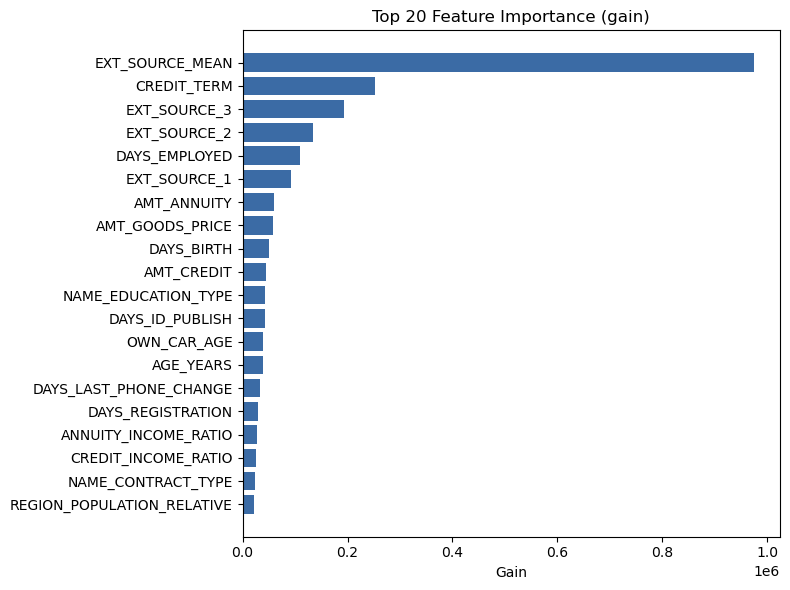

                   feature          gain
           EXT_SOURCE_MEAN 975611.774990
               CREDIT_TERM 251849.760407
              EXT_SOURCE_3 193273.819662
              EXT_SOURCE_2 134031.162582
             DAYS_EMPLOYED 109717.777042
              EXT_SOURCE_1  92040.701621
               AMT_ANNUITY  58993.919860
           AMT_GOODS_PRICE  58793.101678
                DAYS_BIRTH  49839.222397
                AMT_CREDIT  45291.379641
       NAME_EDUCATION_TYPE  43441.253028
           DAYS_ID_PUBLISH  42311.995867
               OWN_CAR_AGE  38854.823971
                 AGE_YEARS  38464.777765
    DAYS_LAST_PHONE_CHANGE  32931.290454
         DAYS_REGISTRATION  29369.401593
      ANNUITY_INCOME_RATIO  27287.426313
       CREDIT_INCOME_RATIO  25967.007029
        NAME_CONTRACT_TYPE  24587.583632
REGION_POPULATION_RELATIVE  22466.860855


In [50]:
model_full = make_lgbm()
model_full.fit(X, y)

gain = (pd.DataFrame({"feature": feature_names,
                      "gain": model_full.booster_.feature_importance(importance_type="gain")})
        .sort_values("gain", ascending=False).reset_index(drop=True))

top = gain.head(20).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["gain"], color="#3B6BA5")
plt.title("Top 20 Feature Importance (gain)"); plt.xlabel("Gain")
plt.tight_layout(); plt.show()
print(gain.head(20).to_string(index=False))

## Fase 7 · Simpan Output

Ekspor hasil per nasabah (PD, skor, tier) + tabel pendukung ke CSV untuk slide & repo.

In [51]:
out = pd.DataFrame({
    "SK_ID_CURR": app["SK_ID_CURR"].values,
    "pd_default": oof_lgb,
    "credit_score": score,
    "risk_tier": tier,
    "target": y,
})
out.to_csv(OUT_DIR / "credit_scores.csv", index=False)
gain.to_csv(OUT_DIR / "feature_importance.csv", index=False)
tier_summary(tier, score, oof_lgb, y).to_csv(OUT_DIR / "tier_summary.csv")
net_profit_table(oof_lgb, amt_credit).to_csv(OUT_DIR / "net_profit_simulation.csv", index=False)

print("Tersimpan di:", OUT_DIR.resolve())
print(out["risk_tier"].value_counts().to_string())

Tersimpan di: D:\Bootcamp\Rakamin\outputs
risk_tier
A_AutoApprove    145936
B_Review         132742
C_Reject          28832
